In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spooky-author-identification/train.zip
/kaggle/input/spooky-author-identification/test.zip
/kaggle/input/spooky-author-identification/sample_submission.zip


# **Prepare Data**

In [2]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import zipfile
from transformers import AutoTokenizer, AutoModelForSequenceClassification,AutoConfig,DataCollatorWithPadding,Trainer,TrainingArguments
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from datasets import load_dataset, Dataset,Features, Value,ClassLabel,Sequence,DatasetDict
import evaluate
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
import torch.nn.functional as F
import torch

2026-02-02 08:00:23.966173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770019224.156365      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770019224.209487      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770019224.648513      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770019224.648545      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770019224.648548      55 computation_placer.cc:177] computation placer alr

In [4]:
zipfile.ZipFile("/kaggle/input/spooky-author-identification/test.zip").extractall("test")
zipfile.ZipFile("/kaggle/input/spooky-author-identification/train.zip").extractall("train")

In [5]:
train_df = pd.read_csv("train/train.csv")
test_df = pd.read_csv("test/test.csv")

# **Explore Data**

In [6]:
train_df.head()

,id,text,author
0,id26305,"This process, however, afforded me no means of...",EAP
1,id17569,It never once occurred to me that the fumbling...,HPL
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP
3,id27763,How lovely is spring As we looked from Windsor...,MWS
4,id12958,"Finding nothing else, not even gold, the Super...",HPL


In [7]:
train_df.shape,test_df.shape

((19579, 3), (8392, 2))

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19579 entries, 0 to 19578
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      19579 non-null  object
 1   text    19579 non-null  object
 2   author  19579 non-null  object
dtypes: object(3)
memory usage: 459.0+ KB


<Axes: xlabel='author', ylabel='count'>

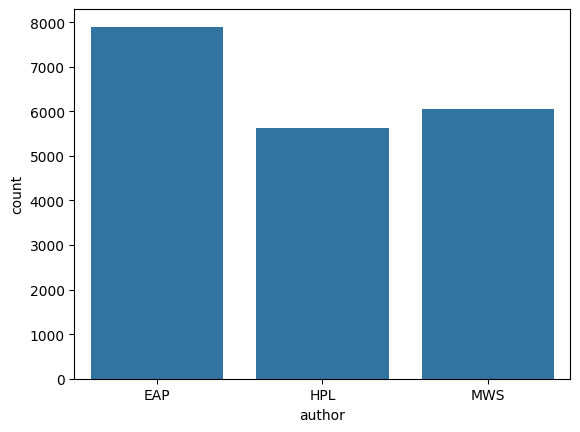

In [9]:
sns.countplot(data=train_df, x="author")

# **Feature Engineer**

In [10]:
train_split,dev_split = train_test_split(train_df,test_size=0.2,random_state=42)
print(f'train shape: {train_split.shape}')
print(f'dev shape: {dev_split.shape}')

train shape: (15663, 3)
dev shape: (3916, 3)


In [11]:
cols_needed = ['text', 'author']
train_clean = train_split[cols_needed].reset_index(drop=True)
dev_clean = dev_split[cols_needed].reset_index(drop=True)

features = Features({
    "text": Value("string"),
    "author": ClassLabel(num_classes=3, names=['EAP', 'HPL', 'MWS'])
})

test_clean = test_df.copy()
if 'author' not in test_clean.columns:
    test_clean['author'] = None
test_clean = test_clean[['id', 'text', 'author']].reset_index(drop=True)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_clean, features=features),
    "dev": Dataset.from_pandas(dev_clean, features=features),
})
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'author'],
        num_rows: 15663
    })
    dev: Dataset({
        features: ['text', 'author'],
        num_rows: 3916
    })
})

# **Model**

In [12]:
model_name = "microsoft/deberta-v3-base"
config = AutoConfig.from_pretrained(model_name,num_labels=3)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name,config=config)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
def tokenize(examples):
    return tokenizer(examples['text'], truncation=True,max_length=128)
tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset

Map:   0%|          | 0/15663 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Map:   0%|          | 0/3916 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'author', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15663
    })
    dev: Dataset({
        features: ['text', 'author', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3916
    })
})

In [14]:
data_collator = DataCollatorWithPadding(tokenizer,padding=True, pad_to_multiple_of=8)
tokenized_dataset["train"].column_names

['text', 'author', 'input_ids', 'token_type_ids', 'attention_mask']

In [15]:
tokenized_dataset = tokenized_dataset.rename_column("author", "labels")

In [17]:
# from transformers import EarlyStoppingCallback
args = TrainingArguments(
    output_dir='prachatai-headline-2',
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    fp16=True, 
    num_train_epochs=10,
    
    load_best_model_at_end=True,
    metric_for_best_model='log_loss',
    greater_is_better=False,
    save_total_limit=2,
    
    eval_strategy='steps',
    eval_steps=100,
    save_strategy='steps',
    save_steps=100,
    logging_steps=50,
    report_to="none",
    
    optim="adamw_torch"
)
def compute_metrics(eval_preds):
    accuracy_metric = evaluate.load("accuracy")
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    probs = F.softmax(torch.tensor(logits), dim=-1).numpy()
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    loss = log_loss(labels, probs) 
    return {
        "accuracy": accuracy["accuracy"],
        "log_loss": loss
    }
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["dev"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    
    # callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] 
)
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Step,Training Loss,Validation Loss,Accuracy,Log Loss,Runtime,Samples Per Second,Steps Per Second
100,0.808100,0.647214,0.742594,0.647214,15.895400,246.361000,30.827000
200,0.528600,0.550535,0.772472,0.550535,15.686100,249.648000,31.238000
300,0.393300,0.459409,0.825077,0.459409,15.629700,250.549000,31.351000
400,0.388300,0.433225,0.835802,0.433225,15.686600,249.640000,31.237000
500,0.372100,0.387598,0.850613,0.387598,15.676700,249.797000,31.256000
600,0.302500,0.395818,0.844995,0.395818,15.620800,250.692000,31.368000
700,0.275800,0.365970,0.861338,0.365970,15.706200,249.329000,31.198000
800,0.214000,0.413634,0.856231,0.413634,15.659700,250.068000,31.290000
900,0.221200,0.410116,0.857508,0.410116,15.608200,250.893000,31.394000
1000,0.186700,0.412523,0.856997,0.412523,15.663800,250.002000,31.282000


TrainOutput(global_step=2450, training_loss=0.21428588750411054, metrics={'train_runtime': 2371.2379, 'train_samples_per_second': 66.054, 'train_steps_per_second': 1.033, 'total_flos': 5577187687727760.0, 'train_loss': 0.21428588750411054, 'epoch': 10.0})

# **Submission**

In [18]:
test_dataset = Dataset.from_pandas(test_df[['text']], preserve_index=False)
def tokenize(examples):
    phrases = [str(x) if x is not None else "" for x in examples['text']]
    return tokenizer(phrases, truncation=True, max_length=128)
tokenized_test = test_dataset.map(tokenize, batched=True)
tokenized_test = tokenized_test.remove_columns(["text"])
tokenized_test.set_format("torch")
print(tokenized_test)

Map:   0%|          | 0/8392 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8392
})


In [19]:
import torch.nn.functional as F
import torch
predictions = trainer.predict(tokenized_test)
probs = F.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
submission = pd.DataFrame({
    'id': test_df['id'],
    'EAP': probs[:, 0],
    'HPL': probs[:, 1],
    'MWS': probs[:, 2]
})
print(submission.head())
submission.to_csv('submission.csv', index=False)
submission.head()

        id       EAP       HPL       MWS
0  id02310  0.084035  0.037730  0.878235
1  id24541  0.935173  0.007098  0.057729
2  id00134  0.002348  0.995443  0.002210
3  id27757  0.982023  0.011256  0.006721
4  id04081  0.663658  0.303845  0.032498


,id,EAP,HPL,MWS
0,id02310,0.084035,0.037730,0.878235
1,id24541,0.935173,0.007098,0.057729
2,id00134,0.002348,0.995443,0.002210
3,id27757,0.982023,0.011256,0.006721
4,id04081,0.663658,0.303845,0.032498
